In [1]:
import numpy as np 
import pandas as pd
import joblib

### Load models

In [9]:
lr_balanced_pipeline=joblib.load("../models/logistic_cw_pipeline.pkl")
lr_smote_pipeline=joblib.load("../models/logistic_smote_pipeline.pkl")
random_forest=joblib.load("../models/random_forest.pkl")
random_forest_tuned=joblib.load("../models/random_forest_tuned.pkl")
xgboost=joblib.load("../models/xgboost.pkl")

### Load test data

In [3]:
x_train,x_test,y_train,y_test=joblib.load("../data/processed/split_data.pkl")

### Create model dictinary

This helps in evaluating models easily

In [10]:
models= {
    "Logistic regression(class weight)" : lr_balanced_pipeline,
    "Logistic regression(SMOTE)" : lr_smote_pipeline,
    "Random forest" : random_forest,
    "Random forest tuned" :random_forest_tuned,
    "XGBoost" : xgboost
}

### Evaluate all models

In [11]:
from sklearn.metrics import recall_score,f1_score,accuracy_score,precision_score
import pandas as pd

results=[]

for name, model in models.items():
    y_pred= model.predict(x_test)

    accuracy=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    precision= precision_score(y_test,y_pred)

    results.append({
        'Model':name,
        'Accuracy':accuracy,
        "recall":recall,
        "F1 score":f1,
        "precision":precision
    })

results_df=pd.DataFrame(results)

results_df


,Model,Accuracy,recall,F1 score,precision
0,Logistic regression(class weight),0.726368,0.796791,0.607543,0.490939
1,Logistic regression(SMOTE),0.732054,0.780749,0.607700,0.497445
2,Random forest,0.786780,0.505348,0.557522,0.621711
3,Random forest tuned,0.759062,0.754011,0.624585,0.533081
4,XGBoost,0.758351,0.537433,0.541779,0.546196


### Final Model Selection

Multiple models were trained and evaluated, including Logistic Regression 
(with class weighting and SMOTE), Random Forest, tuned Random Forest, and XGBoost.

Among these models, the **tuned Random Forest model** achieved the best overall 
performance based on evaluation metrics such as Accuracy, Recall, and F1 Score.

Since the objective of this project is to correctly identify customers likely 
to churn, the model with the best balance between recall and F1-score for the 
churn class was selected as the final model.

Therefore, the **tuned Random Forest model** was chosen as the final model for 
customer churn prediction.

##### Save the best model to the model

In [12]:
joblib.dump(random_forest_tuned,"../models/final_churn_model.pkl")

['../models/final_churn_model.pkl']

### Confusion Matrix


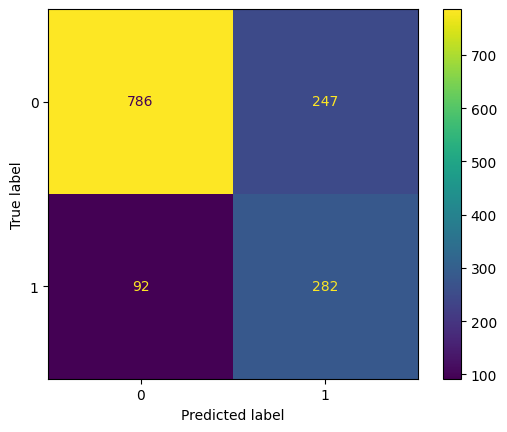

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( random_forest_tuned,x_test,y_test)

### ROC-AUC Curve